# TP1 — Neural Networks & Model Comparison (Heart Disease)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/L2Math/blob/main/session4/tp1_correction.ipynb)

## Objective

In this final TP, we will:
1. Apply the full **data preparation pipeline** to a new dataset
2. Train and compare **three models**: Logistic Regression, Random Forest, and **Neural Network (MLP)**
3. Learn how neural networks work and how to tune them

### New Dataset: Heart Disease

We use the **Heart Disease (Statlog)** dataset — 270 patients with 13 clinical features. The task is to predict the **presence or absence of heart disease**.

Some features are truly numeric (age, blood pressure), while others are integers encoding categories (chest pain type, thal). This is common in real medical datasets.

### Methodology Recap

Same pipeline as always: **Explore → Visualize → Prepare → Train → Evaluate → Compare**

---
## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, f1_score)

import warnings
warnings.filterwarnings('ignore')

---
## 2. Load & Discover the Data

The **Heart Disease (Statlog)** dataset contains clinical data from 270 patients.

**13 features:**
- `age` — Age in years
- `sex` — Sex (1 = male, 0 = female)
- `chest` — Chest pain type (1-4)
- `resting_blood_pressure` — Resting blood pressure (mm Hg)
- `serum_cholestoral` — Serum cholesterol (mg/dl)
- `fasting_blood_sugar` — Fasting blood sugar > 120 mg/dl (1 = yes, 0 = no)
- `resting_electrocardiographic_results` — Resting ECG results (0-2)
- `maximum_heart_rate_achieved` — Maximum heart rate achieved
- `exercise_induced_angina` — Exercise-induced angina (1 = yes, 0 = no)
- `oldpeak` — ST depression induced by exercise
- `slope` — Slope of peak exercise ST segment (1-3)
- `number_of_major_vessels` — Number of major vessels colored by fluoroscopy (0-3)
- `thal` — Thalassemia type (3, 6, or 7)

**Target:** `present` or `absent` — presence of heart disease.

### Exercise 1.1 — Load the dataset

Load the Heart Disease dataset and explore its shape, features, and first rows.

*Hint:* `fetch_openml("heart-statlog", version=1, as_frame=True)`. The target column is called `class`.

In [2]:
data = fetch_openml("heart-statlog", version=1, as_frame=True)
df = data.frame.copy()

# Rename target column and encode to numeric
df = df.rename(columns={'class': 'target'})
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])
# absent=0, present=1

print(f"Shape: {df.shape}")
print(f"\nFeature names: {list(data.feature_names)}")
print(f"\nTarget encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
df.head()

Shape: (270, 14)

Feature names: ['age', 'sex', 'chest', 'resting_blood_pressure', 'serum_cholestoral', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'maximum_heart_rate_achieved', 'exercise_induced_angina', 'oldpeak', 'slope', 'number_of_major_vessels', 'thal']

Target encoding: {'absent': np.int64(0), 'present': np.int64(1)}


,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,target
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


### Exercise 1.2 — Summary statistics and data types

Display summary statistics and check data types. Note which features are truly continuous vs integer-encoded categories.

*Hint:* `df.info()`, `df.describe()`

**Question:** Which features represent categories even though they are stored as numbers?

In [3]:
print("=== Data Info ===")
df.info()

print("\n=== Summary Statistics ===")
df.describe()

=== Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest                                 270 non-null    int64  
 3   resting_blood_pressure                270 non-null    int64  
 4   serum_cholestoral                     270 non-null    int64  
 5   fasting_blood_sugar                   270 non-null    int64  
 6   resting_electrocardiographic_results  270 non-null    int64  
 7   maximum_heart_rate_achieved           270 non-null    int64  
 8   exercise_induced_angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  slope                                 270 non-null    int64  
 11  number_of_ma

,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,target
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000


**Answer:** Features like `sex`, `chest`, `fasting_blood_sugar`, `resting_electrocardiographic_results`, `exercise_induced_angina`, `slope`, and `thal` are integer-encoded categories. They represent discrete medical categories, not continuous measurements. All features are already numeric, so no encoding is needed.

### Exercise 1.3 — Check class balance

Count how many patients have heart disease vs. don't.

**Why:** Same reason as session 1 — check if accuracy is a reliable metric.

*Hint:* `y.value_counts(normalize=True)`

In [4]:
y = df['target']
print("Class counts:")
print(y.value_counts())
print("\nClass proportions:")
print(y.value_counts(normalize=True))
print("\n0 = absent, 1 = present")

Class counts:
target
0    150
1    120
Name: count, dtype: int64

Class proportions:
target
0    0.555556
1    0.444444
Name: proportion, dtype: float64

0 = absent, 1 = present


---
## 3. Data Visualization

Same methodology as sessions 1-2: understand the data visually before modeling.

### Exercise 2.1 — Feature distributions by class

Plot the distribution of `age` and `maximum_heart_rate_achieved`, colored by class.

**Why:** See if these clinical features differ between patients with and without heart disease.

*Hint:* `sns.histplot(data=df, x='age', hue='target', kde=True)`

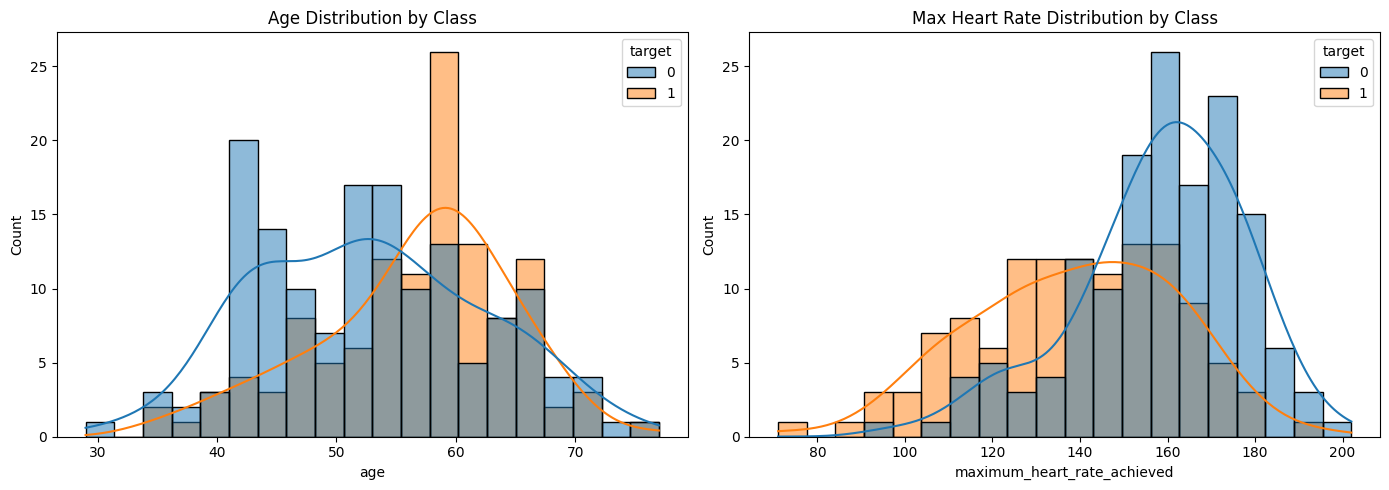

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='age', hue='target', kde=True, ax=axes[0], bins=20)
axes[0].set_title('Age Distribution by Class')

sns.histplot(data=df, x='maximum_heart_rate_achieved', hue='target', kde=True, ax=axes[1], bins=20)
axes[1].set_title('Max Heart Rate Distribution by Class')

plt.tight_layout()
plt.show()

### Exercise 2.2 — Scatter plot

Create a scatter plot of `age` vs `maximum_heart_rate_achieved`, colored by class.

**Why:** See if these two features together help separate the classes.

*Hint:* `sns.scatterplot(x='age', y='maximum_heart_rate_achieved', hue='target', data=df, alpha=0.6)`

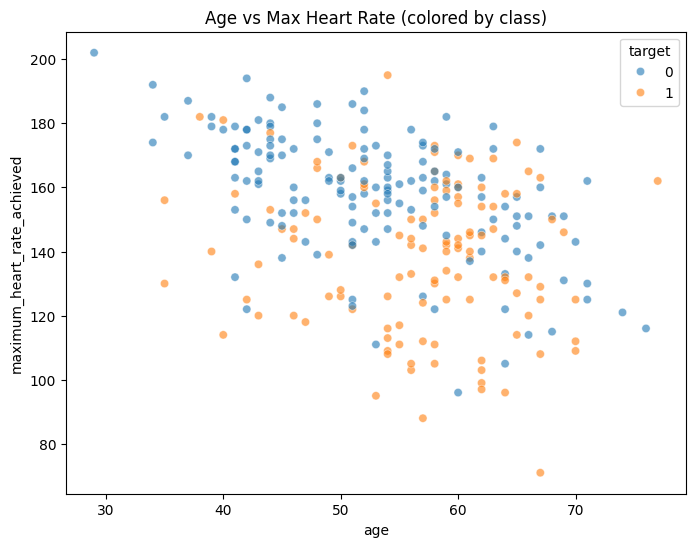

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='maximum_heart_rate_achieved', hue='target', data=df, alpha=0.6)
plt.title('Age vs Max Heart Rate (colored by class)')
plt.show()

### Exercise 2.3 — Correlation heatmap

Compute and display a correlation heatmap for all features.

**Why:** Identify relationships between features and with the target.

*Hint:* `sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')`

**Question:** Which features seem most correlated with heart disease?

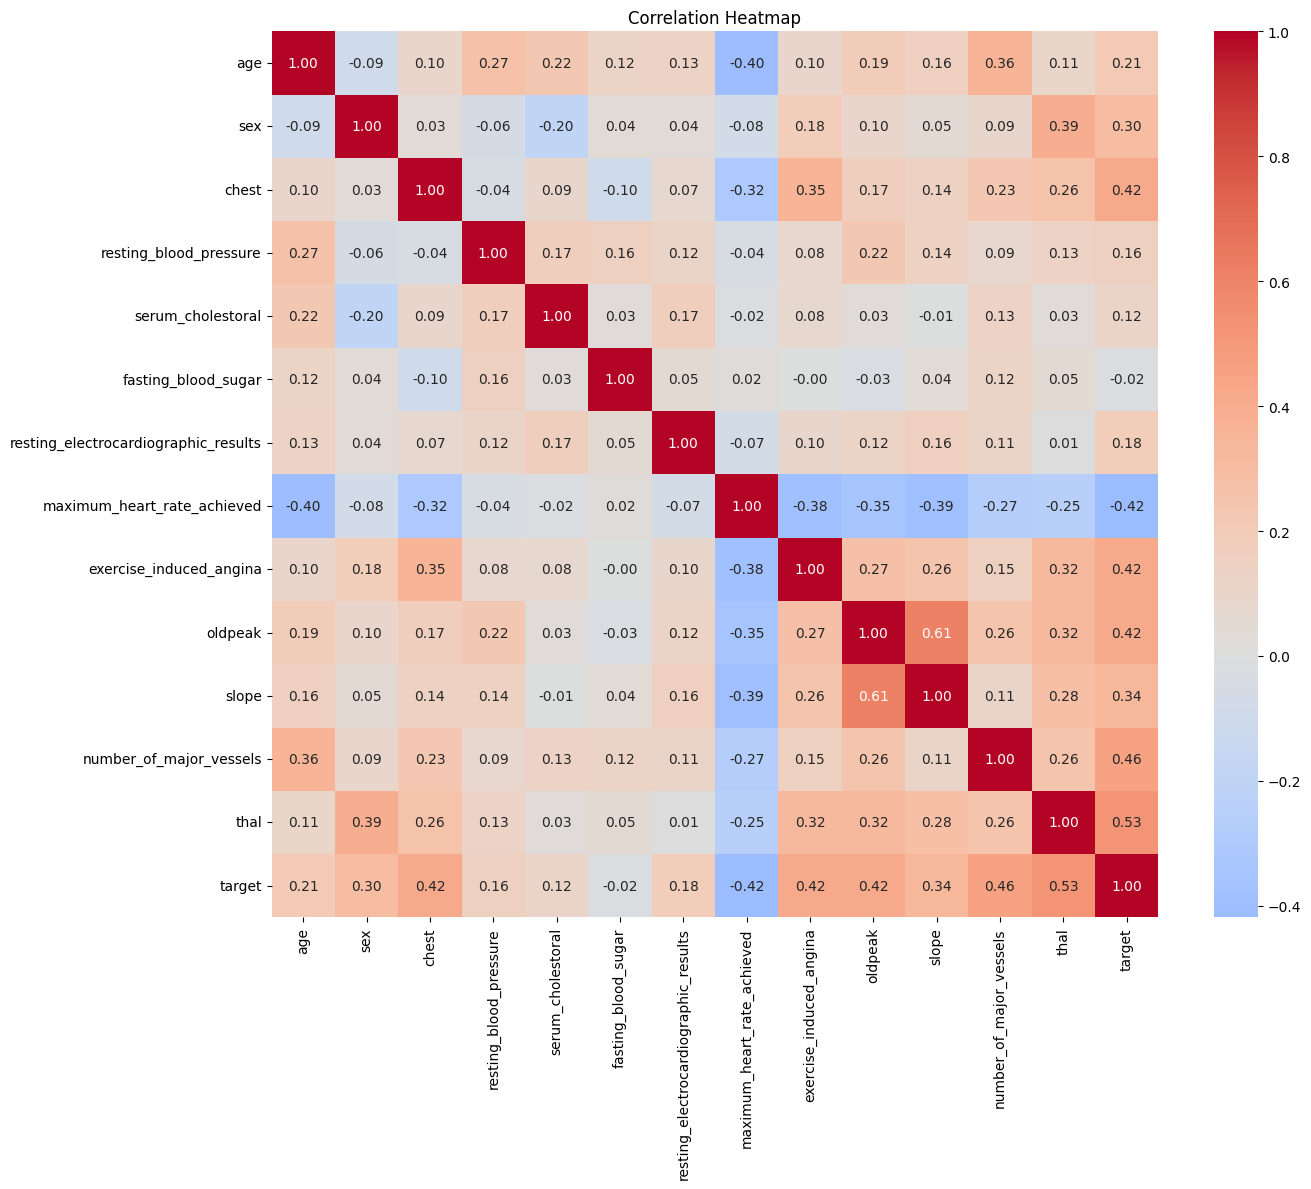


Correlations with target (absolute value):
thal                                    0.525020
number_of_major_vessels                 0.455336
exercise_induced_angina                 0.419303
maximum_heart_rate_achieved             0.418514
oldpeak                                 0.417967
chest                                   0.417436
slope                                   0.337616
sex                                     0.297721
age                                     0.212322
resting_electrocardiographic_results    0.182091
resting_blood_pressure                  0.155383
serum_cholestoral                       0.118021
fasting_blood_sugar                     0.016319
Name: target, dtype: float64


In [7]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Top correlations with target
print("\nCorrelations with target (absolute value):")
print(df.corr()['target'].drop('target').abs().sort_values(ascending=False))

**Answer:** Features like `maximum_heart_rate_achieved`, `oldpeak`, `exercise_induced_angina`, `chest`, and `slope` show the strongest correlations with heart disease. Exercise-related features are particularly informative.

---
## 4. Data Preparation

Apply what you learned in session 2. This dataset has no missing values and all features are already numeric, so we only need to **scale** the features.

**Note:** Some features (sex, chest, fasting_blood_sugar, etc.) are integer-encoded categories. For tree-based models this doesn't matter, but for logistic regression and neural networks, scaling is still important.

### Exercise 3.1 — Split and scale

Split into train/test (80/20, `random_state=42`) and scale with `StandardScaler`.

*Hint:* Same pattern as sessions 1 and 2.

In [8]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Also scale full dataset for cross-validation later
X_scaled = scaler.fit_transform(X)

print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 216 samples, 13 features
Test set: 54 samples


---
## 5. Baseline: Logistic Regression

Always start with a baseline. Logistic regression is our reference model from session 1.

### Exercise 4.1 — Train logistic regression

Train a logistic regression and report accuracy, confusion matrix, and classification report.

*Hint:* `LogisticRegression(max_iter=5000, random_state=42)`

Logistic Regression Accuracy: 0.9074

              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



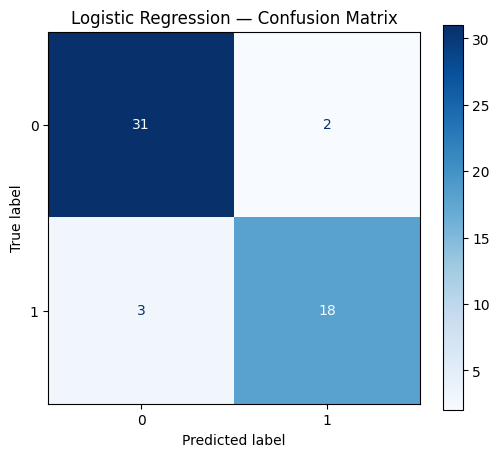

In [9]:
lr_model = LogisticRegression(max_iter=5000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"\n{classification_report(y_test, y_pred_lr)}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=ax, cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

---
## 6. Random Forest

Apply what you learned in session 2 — train a random forest and compare with the baseline.

### Exercise 5.1 — Train a Random Forest

Train a `RandomForestClassifier(n_estimators=100, random_state=42)` and compare with logistic regression.

*Hint:* Same as session 2.

In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest Accuracy:       {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"\n{classification_report(y_test, y_pred_rf)}")

Logistic Regression Accuracy: 0.9074
Random Forest Accuracy:       0.7593

              precision    recall  f1-score   support

           0       0.78      0.85      0.81        33
           1       0.72      0.62      0.67        21

    accuracy                           0.76        54
   macro avg       0.75      0.73      0.74        54
weighted avg       0.76      0.76      0.76        54



---
## 7. Neural Network (MLPClassifier)

### What is a Neural Network?

A **neural network** is inspired by the brain: layers of interconnected "neurons" that transform the input step by step.

### Architecture

```
Input Layer        Hidden Layer(s)       Output Layer
(features)         (learned repr.)       (prediction)

  x₁ ──┐         ┌── h₁ ──┐
        ├─────────┤         ├──────── ŷ (probability)
  x₂ ──┤         ├── h₂ ──┤
        ├─────────┤         ├
  x₃ ──┤         ├── h₃ ──┘
        ├─────────┤
  ...   ┘         └── ...
```

Each connection has a **weight** (like θ in logistic regression). The network **learns** these weights during training.

### Key Differences from Logistic Regression

| | Logistic Regression | Neural Network (MLP) |
|---|---|---|
| **Layers** | 1 (input → output) | Multiple (input → hidden → output) |
| **Decision boundary** | Linear | Non-linear (any shape!) |
| **Parameters** | Few (n_features + 1) | Many (depends on architecture) |
| **Training** | Fast, convex optimization | Slower, non-convex (can get stuck) |
| **Scaling required** | Yes | **Critical** (even more important) |

### MLPClassifier in sklearn

`MLPClassifier` = **Multi-Layer Perceptron** Classifier

Key hyperparameters:
- `hidden_layer_sizes` — e.g., `(100,)` = 1 hidden layer with 100 neurons, `(64, 32)` = 2 layers
- `activation` — `'relu'` (default), `'tanh'`, `'logistic'`
- `learning_rate_init` — initial learning rate (default 0.001)
- `max_iter` — maximum training iterations

> **Medical analogy:** If logistic regression is like a single doctor making a diagnosis based on test results, a neural network is like a team of specialists, each focusing on different patterns, combining their insights for a final diagnosis.

### Exercise 6.1 — Train a basic neural network

Train an `MLPClassifier` with default parameters and compare with previous models.

*Hint:* `MLPClassifier(max_iter=1000, random_state=42)`

In [11]:
mlp_model = MLPClassifier(max_iter=1000, random_state=42)
mlp_model.fit(X_train_scaled, y_train)

y_pred_mlp = mlp_model.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Random Forest Accuracy:       {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Neural Network Accuracy:      {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"\n{classification_report(y_test, y_pred_mlp)}")

Logistic Regression Accuracy: 0.9074
Random Forest Accuracy:       0.7593
Neural Network Accuracy:      0.8333

              precision    recall  f1-score   support

           0       0.83      0.91      0.87        33
           1       0.83      0.71      0.77        21

    accuracy                           0.83        54
   macro avg       0.83      0.81      0.82        54
weighted avg       0.83      0.83      0.83        54



### Exercise 6.2 — Visualize the loss curve

Plot the training loss curve to see how the network learned.

**Why:** The loss curve shows whether the model converged (loss decreasing and stabilizing) or needs more iterations.

*Hint:* `plt.plot(mlp_model.loss_curve_)`, `plt.xlabel('Iteration')`, `plt.ylabel('Loss')`

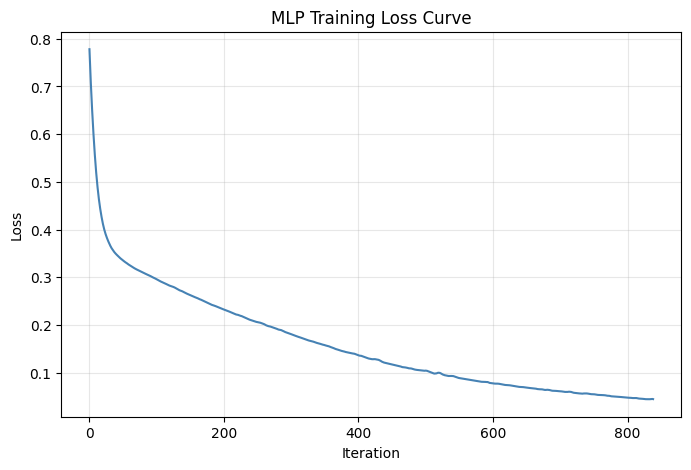

Final loss: 0.0449
Number of iterations: 839


In [12]:
plt.figure(figsize=(8, 5))
plt.plot(mlp_model.loss_curve_, color='steelblue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final loss: {mlp_model.loss_curve_[-1]:.4f}")
print(f"Number of iterations: {mlp_model.n_iter_}")

### Exercise 6.3 — Early stopping

Neural networks can **overfit** if trained for too many iterations. **Early stopping** monitors the validation loss during training and stops when it stops improving.

`MLPClassifier` supports this with:
- `early_stopping=True` — enables early stopping
- `validation_fraction=0.1` — fraction of training data used as validation (default 10%)
- `n_iter_no_change=10` — stop after 10 iterations without improvement (default)

Train an MLP with early stopping and compare its loss curve with the previous one.

*Hint:*
```python
mlp_es = MLPClassifier(max_iter=1000, random_state=42,
                       early_stopping=True, validation_fraction=0.1)
mlp_es.fit(X_train_scaled, y_train)
# mlp_es.validation_scores_ contains the validation accuracy at each iteration
```

Without early stopping — Accuracy: 0.8333  Iterations: 839
With early stopping    — Accuracy: 0.8148  Iterations: 27


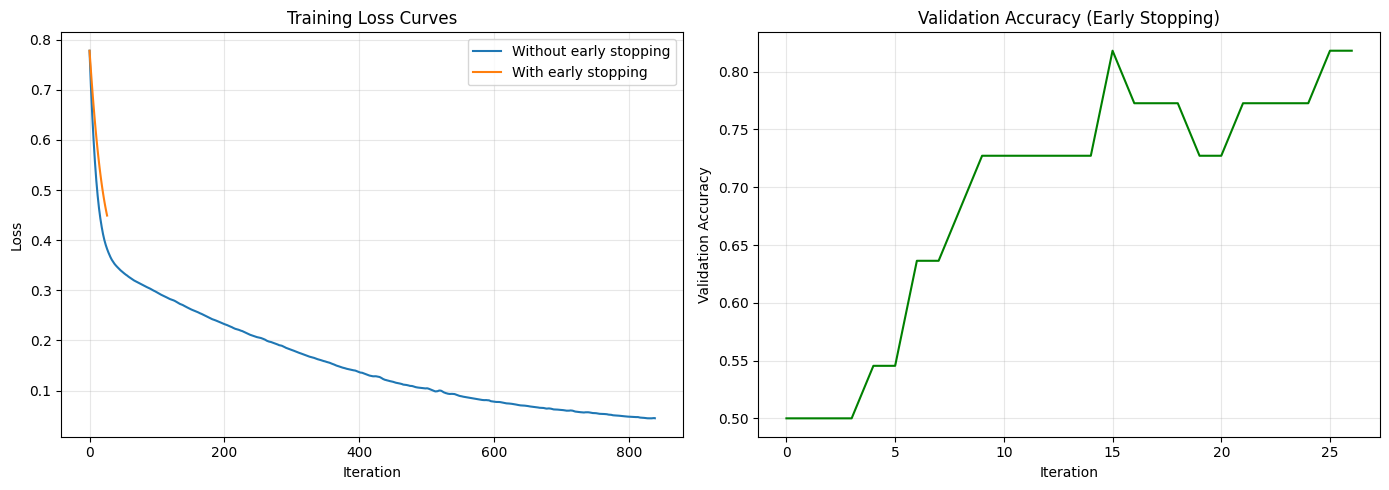


Early stopping stopped at iteration 27 (max was 1000)
Best validation score: 0.8182


In [13]:
mlp_es = MLPClassifier(max_iter=1000, random_state=42,
                       early_stopping=True, validation_fraction=0.1)
mlp_es.fit(X_train_scaled, y_train)

y_pred_mlp_es = mlp_es.predict(X_test_scaled)

print(f"Without early stopping — Accuracy: {accuracy_score(y_test, y_pred_mlp):.4f}  Iterations: {mlp_model.n_iter_}")
print(f"With early stopping    — Accuracy: {accuracy_score(y_test, y_pred_mlp_es):.4f}  Iterations: {mlp_es.n_iter_}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(mlp_model.loss_curve_, label='Without early stopping')
axes[0].plot(mlp_es.loss_curve_, label='With early stopping')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation accuracy curve (only available with early stopping)
axes[1].plot(mlp_es.validation_scores_, color='green')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy (Early Stopping)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEarly stopping stopped at iteration {mlp_es.n_iter_} (max was 1000)")
print(f"Best validation score: {mlp_es.best_validation_score_:.4f}")

---
## 8. Tuning the Neural Network

### Experimenting with Architecture

The architecture of a neural network (number and size of hidden layers) greatly affects its performance:

| Architecture | Description | When to use |
|-------------|-------------|-------------|
| `(50,)` | 1 layer, 50 neurons | Simple problems |
| `(100,)` | 1 layer, 100 neurons | Default, good starting point |
| `(64, 32)` | 2 layers (64 → 32) | More complex patterns |
| `(128, 64, 32)` | 3 layers | Complex problems, more data needed |

**Rule of thumb:** Start simple, add complexity only if needed. More layers ≠ better performance (especially with small datasets).

### Exercise 7.1 — Experiment with architectures

Try different `hidden_layer_sizes` and compare results. Plot the loss curves together. Use `early_stopping=True` on all models.

*Hint:*
```python
architectures = [(50,), (100,), (64, 32), (128, 64, 32)]
for arch in architectures:
    model = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000, random_state=42,
                          early_stopping=True)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{str(arch):<20} Accuracy: {acc:.4f}")
    plt.plot(model.loss_curve_, label=str(arch))
```

(50,)                Accuracy: 0.6111  (iterations: 26)
(100,)               Accuracy: 0.8148  (iterations: 27)
(64, 32)             Accuracy: 0.7778  (iterations: 19)
(128, 64, 32)        Accuracy: 0.7593  (iterations: 28)


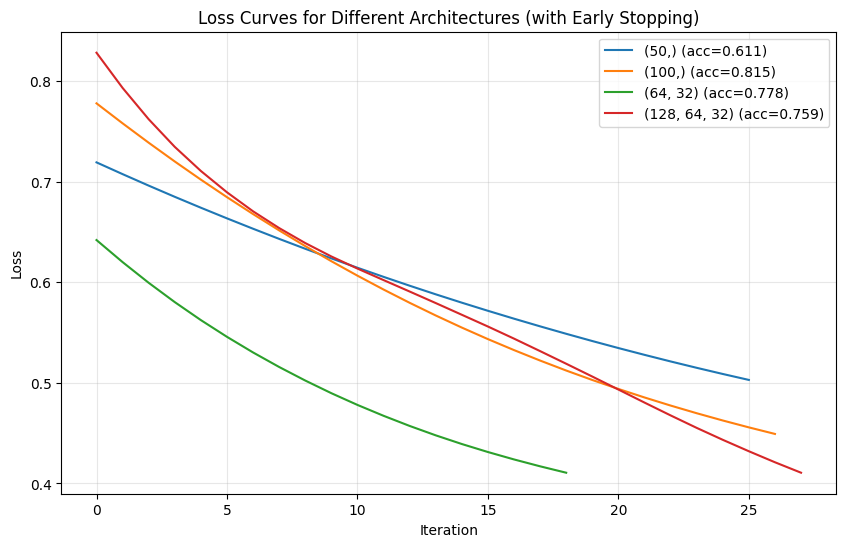

In [14]:
architectures = [(50,), (100,), (64, 32), (128, 64, 32)]

plt.figure(figsize=(10, 6))

for arch in architectures:
    model = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000, random_state=42,
                          early_stopping=True)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    print(f"{str(arch):<20} Accuracy: {acc:.4f}  (iterations: {model.n_iter_})")
    plt.plot(model.loss_curve_, label=f"{arch} (acc={acc:.3f})")

plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Curves for Different Architectures (with Early Stopping)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Exercise 7.2 — Grid search for best MLP

Use `GridSearchCV` to find the best combination of `hidden_layer_sizes`, `activation`, and `learning_rate_init`. Use `early_stopping=True`.

*Hint:*
```python
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (64, 32)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01]
}
grid_search_mlp = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=42, early_stopping=True),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1)
```

In [18]:
param_grid = {
    'hidden_layer_sizes': [(200,64, 32,), (50,), (200,), (64, 32)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01]
}

grid_search_mlp = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=42, early_stopping=True),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search_mlp.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search_mlp.best_params_}")
print(f"Best CV accuracy: {grid_search_mlp.best_score_:.4f}")

y_pred_best_mlp = grid_search_mlp.best_estimator_.predict(X_test_scaled)
print(f"Test accuracy: {accuracy_score(y_test, y_pred_best_mlp):.4f}")

Best parameters: {'activation': 'tanh', 'hidden_layer_sizes': (200, 64, 32), 'learning_rate_init': 0.01}
Best CV accuracy: 0.8198
Test accuracy: 0.8519


---
## 9. Final Model Comparison

Now let's compare all three models systematically.

### Exercise 8.1 — Cross-validation comparison

Run 5-fold cross-validation for all three models and create a comparison table.

*Hint:*
```python
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Neural Network (MLP)': grid_search_mlp.best_estimator_
}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    print(f"{name:<25} {scores.mean():.4f} ± {scores.std():.4f}")
```

In [19]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Neural Network (MLP)': grid_search_mlp.best_estimator_
}

print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>12} {'Std':>12}")
print("=" * 55)

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    print(f"{name:<25} {scores.mean():>12.4f} {scores.std():>12.4f}")

print("=" * 55)

Model                         Accuracy          Std
Logistic Regression             0.8407       0.0323
Random Forest                   0.8148       0.0609
Neural Network (MLP)            0.8481       0.0429


### Exercise 8.2 — Confusion matrices comparison

Display confusion matrices for all three models side by side.

*Hint:* `fig, axes = plt.subplots(1, 3, figsize=(18, 5))`

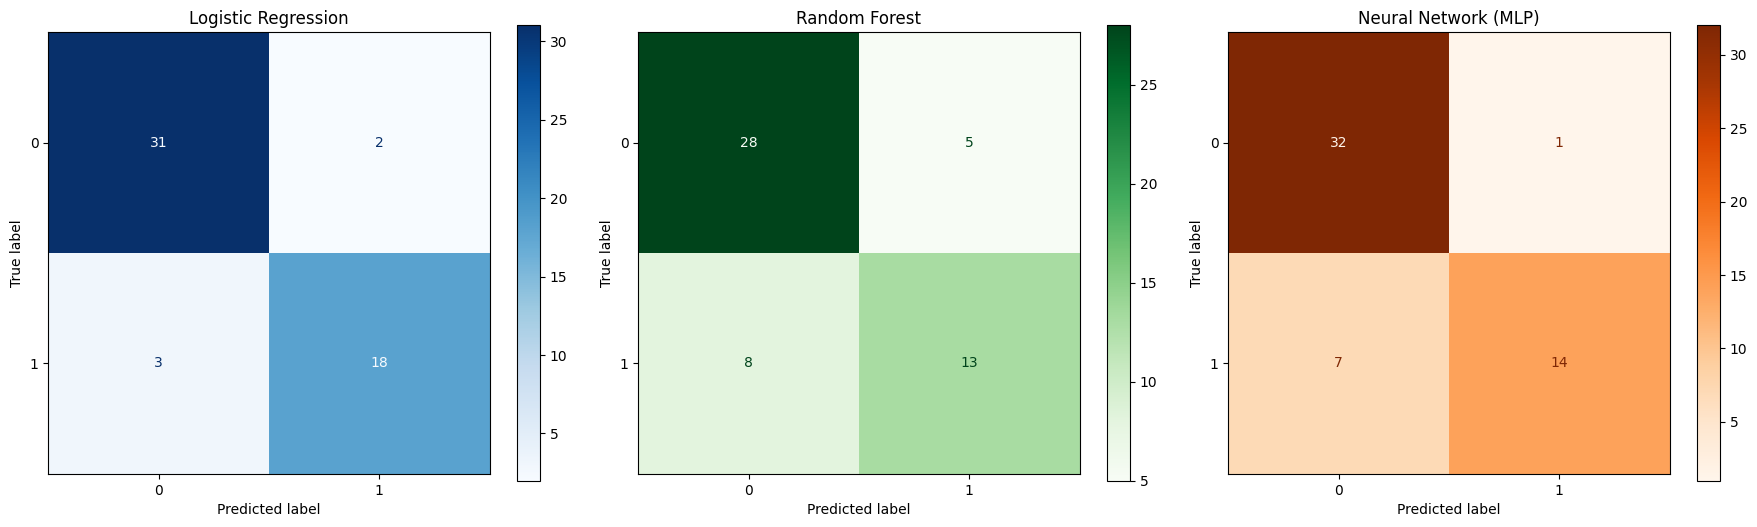

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_pred = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'Neural Network (MLP)': y_pred_best_mlp
}
cmaps = ['Blues', 'Greens', 'Oranges']

for ax, (name, y_pred), cmap in zip(axes, models_pred.items(), cmaps):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap=cmap)
    ax.set_title(name)

plt.tight_layout()
plt.show()